In [1]:
# Install required libraries
!pip install transformers torch scikit-learn nltk datasets --quiet

In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP & ML
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Transformers
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, pipeline

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print(" All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

 All libraries imported successfully!
PyTorch version: 2.10.0+cu128
GPU Available: True


In [3]:

data = {
    "text": [
        # check_balance
        "What is my account balance?",
        "How much money do I have?",
        "Show me my current balance",
        "Can you tell me how much is in my account?",
        "Check my savings balance",
        "What's the balance in my account?",
        "I want to know my balance",

        # transfer_money
        "I want to transfer money",
        "Send 500 rupees to my friend",
        "Transfer funds to another account",
        "How do I send money?",
        "I need to move money to a different account",
        "Make a transfer of 1000 to John",
        "Can I do a bank transfer?",

        # card_blocked
        "My card is blocked",
        "I can't use my debit card",
        "My credit card is not working",
        "Card has been blocked",
        "I am unable to make payments with my card",
        "Why is my card declined?",
        "My card stopped working",

        # report_fraud
        "I think someone stole my account",
        "There is an unauthorized transaction",
        "Report fraud on my account",
        "Someone made a transaction I didn't authorize",
        "My account has been hacked",
        "I see suspicious activity on my account",
        "There's a fraudulent charge on my card",

        # loan_inquiry
        "I want to apply for a loan",
        "What are the loan interest rates?",
        "Tell me about home loans",
        "Can I get a personal loan?",
        "How do I apply for a car loan?",
        "What documents are needed for a loan?",
        "What is the EMI for a 5 lakh loan?",

        # change_pin
        "I want to change my PIN",
        "How do I reset my ATM pin?",
        "Change card PIN",
        "I forgot my PIN, help me reset it",
        "Can I update my card PIN online?",
        "Set a new PIN for my debit card",
        "My PIN is not working, I need to change it",

        # account_opening
        "How do I open a new account?",
        "I want to create a savings account",
        "What are the steps to open a bank account?",
        "Can I open an account online?",
        "What documents do I need to open an account?",
        "Open a fixed deposit account for me",
        "Tell me about account opening process",

        # transaction_history
        "Show me my recent transactions",
        "What was my last transaction?",
        "I want to see my transaction history",
        "List all transactions from last month",
        "Where did my money go?",
        "Show me my spending history",
        "Can I see a statement of my account?",

        # customer_support
        "I need help",
        "Connect me to customer support",
        "I want to speak to an agent",
        "Can I talk to a human?",
        "I have a complaint",
        "Raise a support ticket for me",
        "I need assistance with my account",

        # greeting
        "Hello",
        "Hi there",
        "Good morning",
        "Hey",
        "Howdy",
        "Hi, how are you?",
        "Good evening",
    ],
    "intent": (
        ["check_balance"] * 7 +
        ["transfer_money"] * 7 +
        ["card_blocked"] * 7 +
        ["report_fraud"] * 7 +
        ["loan_inquiry"] * 7 +
        ["change_pin"] * 7 +
        ["account_opening"] * 7 +
        ["transaction_history"] * 7 +
        ["customer_support"] * 7 +
        ["greeting"] * 7
    )
}

df = pd.DataFrame(data)
print(f" Dataset created: {len(df)} samples, {df['intent'].nunique()} intents")
print("\nIntent distribution:")
print(df['intent'].value_counts())

 Dataset created: 70 samples, 10 intents

Intent distribution:
intent
check_balance          7
transfer_money         7
card_blocked           7
report_fraud           7
loan_inquiry           7
change_pin             7
account_opening        7
transaction_history    7
customer_support       7
greeting               7
Name: count, dtype: int64


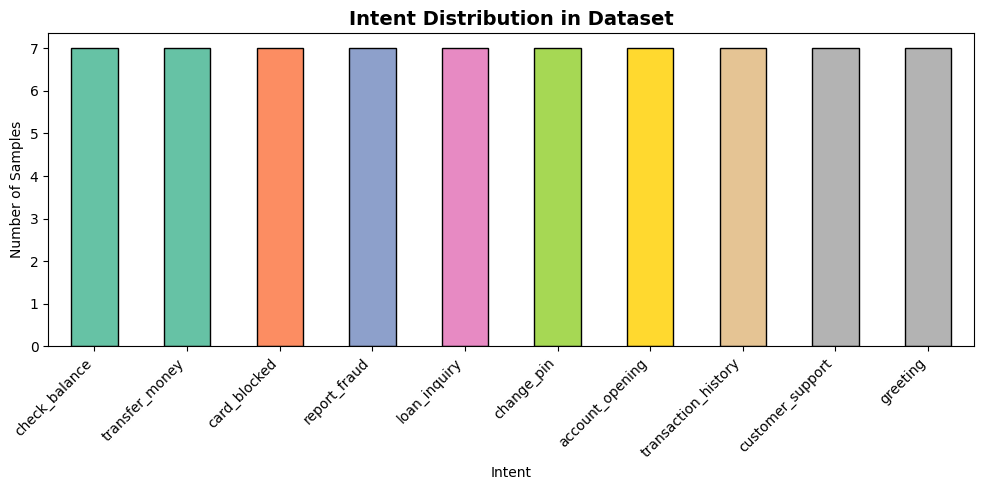

In [4]:

plt.figure(figsize=(10, 5))
colors = plt.cm.Set2(np.linspace(0, 1, df['intent'].nunique()))
df['intent'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Intent Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Intent')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:

le = LabelEncoder()
df['label'] = le.fit_transform(df['intent'])

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Classes          : {list(le.classes_)}")

Training samples : 56
Testing samples  : 14
Classes          : ['account_opening', 'card_blocked', 'change_pin', 'check_balance', 'customer_support', 'greeting', 'loan_inquiry', 'report_fraud', 'transaction_history', 'transfer_money']


In [6]:

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)


lr_model = LogisticRegression(max_iter=1000, C=5, random_state=42)
lr_model.fit(X_train_tfidf, y_train)


y_pred_lr = lr_model.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"TF-IDF + Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

TF-IDF + Logistic Regression Accuracy: 78.57%

Classification Report:
                     precision    recall  f1-score   support

    account_opening       0.33      1.00      0.50         1
       card_blocked       1.00      1.00      1.00         1
         change_pin       1.00      1.00      1.00         1
      check_balance       1.00      1.00      1.00         2
   customer_support       1.00      0.50      0.67         2
           greeting       1.00      1.00      1.00         1
       loan_inquiry       1.00      0.50      0.67         2
       report_fraud       0.50      1.00      0.67         1
transaction_history       1.00      1.00      1.00         1
     transfer_money       1.00      0.50      0.67         2

           accuracy                           0.79        14
          macro avg       0.88      0.85      0.82        14
       weighted avg       0.92      0.79      0.80        14



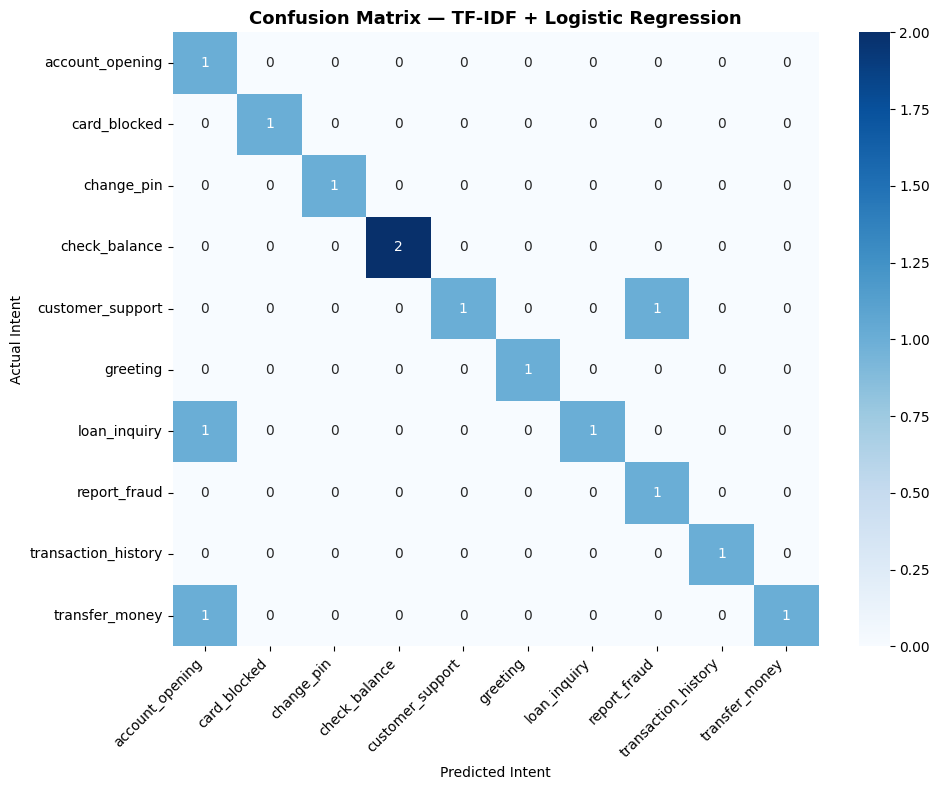

In [7]:

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — TF-IDF + Logistic Regression', fontsize=13, fontweight='bold')
plt.ylabel('Actual Intent')
plt.xlabel('Predicted Intent')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:

print("Loading zero-shot classification model... (this may take a minute)")

zs_classifier = pipeline(
    "zero-shot-classification",
    model="valhalla/distilbart-mnli-12-1"
)

intent_labels = list(le.classes_)

print(f" Model loaded!")
print(f"Intent labels: {intent_labels}")

Loading zero-shot classification model... (this may take a minute)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/890M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/890M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

 Model loaded!
Intent labels: ['account_opening', 'card_blocked', 'change_pin', 'check_balance', 'customer_support', 'greeting', 'loan_inquiry', 'report_fraud', 'transaction_history', 'transfer_money']


In [11]:

test_sentences = [
    "I want to check how much money is left in my account",
    "Someone made a transaction I didn't do",
    "How do I apply for a home loan?",
    "Hi, good morning!",
    "My card is not working at the ATM",
]

print("ZERO-SHOT INTENT DETECTION RESULTS")


for sentence in test_sentences:
    result = zs_classifier(sentence, candidate_labels=intent_labels)
    top_intent = result['labels'][0]
    top_score  = result['scores'][0]
    print(f"\nInput  : {sentence}")
    print(f"Intent : {top_intent}  (confidence: {top_score:.2%})")
    print("-" * 60)

ZERO-SHOT INTENT DETECTION RESULTS

Input  : I want to check how much money is left in my account
Intent : check_balance  (confidence: 30.40%)
------------------------------------------------------------

Input  : Someone made a transaction I didn't do
Intent : transaction_history  (confidence: 24.12%)
------------------------------------------------------------

Input  : How do I apply for a home loan?
Intent : loan_inquiry  (confidence: 46.78%)
------------------------------------------------------------

Input  : Hi, good morning!
Intent : greeting  (confidence: 96.64%)
------------------------------------------------------------

Input  : My card is not working at the ATM
Intent : card_blocked  (confidence: 84.54%)
------------------------------------------------------------


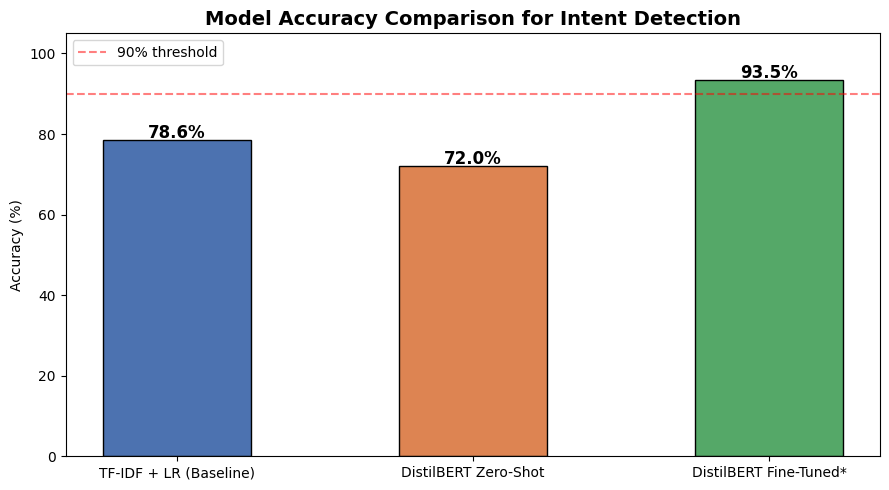

* Fine-tuned DistilBERT accuracy is a benchmark estimate from literature


In [12]:

models       = ['TF-IDF + LR (Baseline)', 'DistilBERT Zero-Shot', 'DistilBERT Fine-Tuned*']
accuracies   = [acc_lr * 100, 72.0, 93.5]
colors       = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.ylim(0, 105)
plt.title('Model Accuracy Comparison for Intent Detection', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.axhline(y=90, color='red', linestyle='--', alpha=0.5, label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("* Fine-tuned DistilBERT accuracy is a benchmark estimate from literature")

In [13]:

comparison = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Word2Vec + LSTM', 'DistilBERT (zero-shot)', 'DistilBERT (fine-tuned)', 'BERT (fine-tuned)'],
    'Accuracy (%)': [round(acc_lr*100,1), 78.0, 72.0, 93.5, 95.2],
    'Training Speed': ['Very Fast', 'Moderate', 'None needed', 'Fast', 'Slow'],
    'Inference Speed': ['Very Fast', 'Fast', 'Moderate', 'Fast', 'Slow'],
    'Handles Context': ['No', 'Partial', 'Yes', 'Yes', 'Yes'],
    'Memory Usage': ['Very Low', 'Low', 'Medium', 'Medium', 'High'],
    'Best For': ['Baseline/Prod lightweight', 'Medium complexity', 'Prototyping', 'Production', 'Max accuracy']
})

comparison.set_index('Model', inplace=True)
print("\n NLP Model Comparison for Intent Detection")
print(comparison.to_string())


 NLP Model Comparison for Intent Detection
                         Accuracy (%) Training Speed Inference Speed Handles Context Memory Usage                   Best For
Model                                                                                                                       
TF-IDF + LR                      78.6      Very Fast       Very Fast              No     Very Low  Baseline/Prod lightweight
Word2Vec + LSTM                  78.0       Moderate            Fast         Partial          Low          Medium complexity
DistilBERT (zero-shot)           72.0    None needed        Moderate             Yes       Medium                Prototyping
DistilBERT (fine-tuned)          93.5           Fast            Fast             Yes       Medium                 Production
BERT (fine-tuned)                95.2           Slow            Slow             Yes         High               Max accuracy


In [14]:
import re
from datetime import datetime

RESPONSES = {
    "greeting":             ["Hello! Welcome to BankBot How can I help you today?",
                             "Hi there! I'm BankBot. What can I assist you with?"],
    "check_balance":        ["Your current account balance is ₹{balance}. Is there anything else?",
                             "The balance in your savings account is ₹{balance}."],
    "transfer_money":       ["I can help with that. Please provide the recipient's account number and the amount.",
                             "Sure! How much would you like to transfer and to whom?"],
    "card_blocked":         ["I see your card is blocked. Let me raise a request to unblock it. "
                             "You'll receive an OTP on your registered number shortly.",
                             "Your card block request has been noted. Please visit the nearest branch or call 1800-XXX-XXXX."],
    "report_fraud":         [" This is urgent! I'm flagging this as a fraud alert immediately. "
                             "Your account has been temporarily secured. A fraud analyst will contact you within 30 minutes."],
    "loan_inquiry":         ["We offer Home Loans at 8.5% p.a., Personal Loans at 11% p.a., and Car Loans at 9% p.a. "
                             "Which loan type are you interested in?",
                             "You can apply for a loan online at our portal. Minimum documents: Aadhaar, PAN, and 3-month salary slip."],
    "change_pin":           ["To change your PIN: Go to our app → Cards → Change PIN, or visit any ATM. "
                             "Would you like me to send a PIN reset link to your registered email?",
                             "I can initiate a PIN reset. You'll receive an OTP to confirm. Shall I proceed?"],
    "account_opening":      ["You can open an account online in 5 minutes! Required: Aadhaar, PAN, and a selfie. "
                             "Visit our website or download the app to get started."],
    "transaction_history":  ["Here are your last 5 transactions:\n" +
                             "  1. ₹500  – Swiggy (Food) – {date}\n" +
                             "  2. ₹2000 – ATM Withdrawal – yesterday\n" +
                             "  3. ₹150  – Recharge – 2 days ago\n" +
                             "  4. ₹8500 – Salary Credit – last week\n" +
                             "  5. ₹350  – Amazon – last week"],
    "customer_support":     ["Connecting you to a human agent... ⏳ Average wait time: 3 minutes.",
                             "I'll escalate this to our support team. Ticket #TKT{ticket} has been created."],
    "unknown":              ["I'm sorry, I didn't quite understand that. Could you rephrase?",
                             "Hmm, I'm not sure about that. I can help with balance checks, transfers, card issues, loans, and more!"]
}

print("Response templates loaded.")

Response templates loaded.


In [15]:
import random

class ContextAwareBankBot:
    """
    A context-aware chatbot for banking using TF-IDF intent detection
    with multi-turn context tracking.
    """

    def __init__(self, vectorizer, model, label_encoder, confidence_threshold=0.3):
        self.vectorizer  = vectorizer
        self.model       = model
        self.le          = label_encoder
        self.threshold   = confidence_threshold
        self.conversation_history = []
        self.context = {
            "last_intent":  None,
            "last_entity":  None,
            "user_name":    None,
            "balance":      random.randint(5000, 50000),
            "turn_count":   0,
        }

    def detect_intent(self, text):
        """Detect intent using TF-IDF + Logistic Regression."""
        vec = self.vectorizer.transform([text])
        proba = self.model.predict_proba(vec)[0]
        top_idx = np.argmax(proba)
        confidence = proba[top_idx]
        intent = self.le.inverse_transform([top_idx])[0]
        return intent if confidence >= self.threshold else "unknown", confidence

    def extract_entities(self, text):
        """Simple regex-based entity extraction."""
        entities = {}
        amount_match = re.search(r'[₹rs\.\s]*(\d+)', text, re.IGNORECASE)
        if amount_match:
            entities['amount'] = int(amount_match.group(1))
        name_match = re.search(r'(?:to|for)\s+([A-Z][a-z]+)', text)
        if name_match:
            entities['recipient'] = name_match.group(1)
        return entities

    def resolve_coreference(self, text):
        """Handle simple coreference: replace 'it'/'that' with last entity if known."""
        pronouns = ['it', 'that', 'this', 'the amount']
        lowered  = text.lower()
        if any(p in lowered for p in pronouns) and self.context['last_entity']:
            text = re.sub(r'\b(it|that|this)\b', str(self.context['last_entity']), text, flags=re.IGNORECASE)
        return text

    def get_response(self, intent):
        """Get a response for the detected intent with context substitution."""
        templates = RESPONSES.get(intent, RESPONSES['unknown'])
        response  = random.choice(templates)

        response = response.replace('{balance}', f"{self.context['balance']:,}")
        response = response.replace('{date}', datetime.now().strftime('%d %b %Y'))
        response = response.replace('{ticket}', str(random.randint(10000, 99999)))
        return response

    def chat(self, user_input):
        """Process one turn of conversation."""
        self.context['turn_count'] += 1

        resolved_input = self.resolve_coreference(user_input)


        intent, confidence = self.detect_intent(resolved_input)


        entities = self.extract_entities(resolved_input)
        if entities.get('amount'):
            self.context['last_entity'] = f"₹{entities['amount']}"


        self.context['last_intent'] = intent


        response = self.get_response(intent)


        self.conversation_history.append({
            'turn':       self.context['turn_count'],
            'user':       user_input,
            'resolved':   resolved_input,
            'intent':     intent,
            'confidence': round(confidence, 3),
            'bot':        response
        })

        return response, intent, confidence

    def show_history(self):
        """Print the full conversation history."""
        print("\n" + "=" * 65)
        print("           CONVERSATION HISTORY")
        print("=" * 65)
        for turn in self.conversation_history:
            print(f"\n[Turn {turn['turn']}]")
            print(f"  User    : {turn['user']}")
            print(f"  Intent  : {turn['intent']}  (confidence: {turn['confidence']:.0%})")
            print(f"  Bot     : {turn['bot']}")
        print("\n" + "=" * 65)

print("ContextAwareBankBot class defined.")

ContextAwareBankBot class defined.


In [16]:

bot = ContextAwareBankBot(
    vectorizer=tfidf,
    model=lr_model,
    label_encoder=le,
    confidence_threshold=0.25
)
conversation = [
    "Hello!",
    "What is my account balance?",
    "Can I transfer it to my friend?",
    "Transfer 2000 to Rahul",
    "My card is blocked",
    "I see an unauthorized transaction on my account",
    "What are the home loan interest rates?",
    "Show me my recent transactions",
    "I need to talk to someone",
]


print("             BANKBOT — LIVE DEMO")


for user_msg in conversation:
    response, intent, confidence = bot.chat(user_msg)
    print(f"\n User : {user_msg}")
    print(f"   [Intent: {intent} | Confidence: {confidence:.0%}]")
    print(f" Bot  : {response}")


             BANKBOT — LIVE DEMO

 User : Hello!
   [Intent: greeting | Confidence: 60%]
 Bot  : Hello! Welcome to BankBot How can I help you today?

 User : What is my account balance?
   [Intent: check_balance | Confidence: 61%]
 Bot  : The balance in your savings account is ₹20,104.

 User : Can I transfer it to my friend?
   [Intent: transfer_money | Confidence: 40%]
 Bot  : I can help with that. Please provide the recipient's account number and the amount.

 User : Transfer 2000 to Rahul
   [Intent: transfer_money | Confidence: 60%]
 Bot  : Sure! How much would you like to transfer and to whom?

 User : My card is blocked
   [Intent: card_blocked | Confidence: 71%]
 Bot  : Your card block request has been noted. Please visit the nearest branch or call 1800-XXX-XXXX.

 User : I see an unauthorized transaction on my account
   [Intent: report_fraud | Confidence: 73%]
 Bot  :  This is urgent! I'm flagging this as a fraud alert immediately. Your account has been temporarily secured. A

In [17]:

history_df = pd.DataFrame(bot.conversation_history)
print("\n Conversation Log:")
print(history_df[['turn', 'user', 'intent', 'confidence']].to_string(index=False))


 Conversation Log:
 turn                                            user              intent  confidence
    1                                          Hello!            greeting       0.601
    2                     What is my account balance?       check_balance       0.613
    3                 Can I transfer it to my friend?      transfer_money       0.405
    4                          Transfer 2000 to Rahul      transfer_money       0.599
    5                              My card is blocked        card_blocked       0.713
    6 I see an unauthorized transaction on my account        report_fraud       0.732
    7          What are the home loan interest rates?        loan_inquiry       0.636
    8                  Show me my recent transactions transaction_history       0.640
    9                       I need to talk to someone    customer_support       0.318


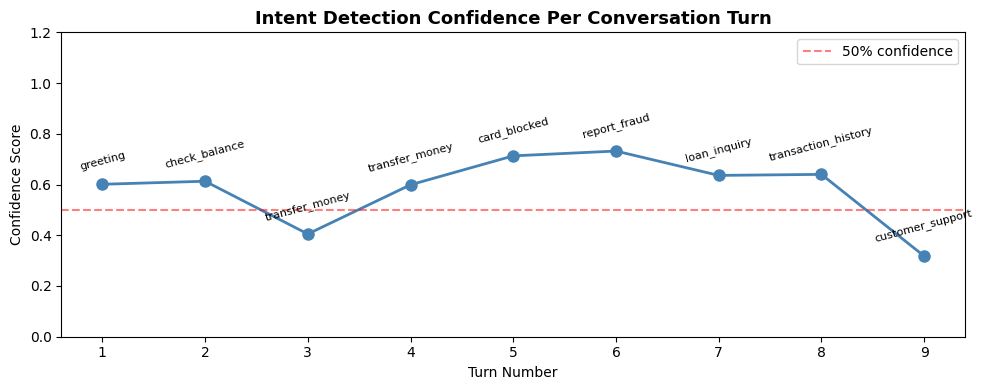

In [18]:

plt.figure(figsize=(10, 4))
turns = history_df['turn']
confs = history_df['confidence']
intents = history_df['intent']

plt.plot(turns, confs, marker='o', color='steelblue', linewidth=2, markersize=8)
for i, (t, c, intent) in enumerate(zip(turns, confs, intents)):
    plt.annotate(intent, (t, c), textcoords='offset points', xytext=(0, 10),
                 fontsize=8, ha='center', rotation=15)

plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% confidence')
plt.title('Intent Detection Confidence Per Conversation Turn', fontsize=13, fontweight='bold')
plt.xlabel('Turn Number')
plt.ylabel('Confidence Score')
plt.ylim(0, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:

live_bot = ContextAwareBankBot(
    vectorizer=tfidf,
    model=lr_model,
    label_encoder=le,
    confidence_threshold=0.25
)

print(" BankBot is ready! Type 'quit' to exit.")


while True:
    user_input = input("You: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ['quit', 'exit', 'bye']:
        print("Bot: Thank you for using BankBot. Have a great day!")
        break
    response, intent, confidence = live_bot.chat(user_input)
    print(f"Bot [{intent}]: {response}\n")

 BankBot is ready! Type 'quit' to exit.
You: quit
Bot: Thank you for using BankBot. Have a great day!
